In [1]:
import json
import matplotlib.pyplot as plt
import sys
import numpy as np
plt.rcParams['text.usetex'] = (sys.platform == "darwin")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
plt.rcParams['font.size'] = 9

In [2]:
pde_configs = {
    'schrodinger': {'title': r'Schrodinger PDE'},
    'heat': {'title': r'Heat PDE'},
    'fokkerplanck': {'title': r'Fokker-Planck PDE'},
    'poisson2d': {'title': r'2D Poisson PDE'},
}

# Same convention train_pinn.py already uses to pick its plot kappa (common.plotting.best_pade_pinn_kappa):
# the held-out kappa where Pade+PINN reached its lowest Rel_MSE within the training horizon.
best_kappa = {}
for type_ in pde_configs:
    with open(f'./models/pade_pinn_{type_}_error_metrics.json') as f:
        metrics = json.load(f)
    best_key, best_mse = next(iter(metrics)), float('inf')
    for key, entry in metrics.items():
        if entry['Rel_MSE'][1] < best_mse:
            best_key, best_mse = key, entry['Rel_MSE'][1]
    best_kappa[type_] = float(best_key)

best_kappa

{'schrodinger': 0.10100963958256941,
 'heat': 0.010320694131244432,
 'fokkerplanck': 0.9132322581440309,
 'poisson2d': 0.010996058064280993}

In [3]:
pde_configs2 = {
    'burgers': {'title': r'Burgers PDE'},
    'allencahn': {'title': r'Allen-Cahn 1D PDE'},
    'heat2d': {'title': r'2D Heat PDE'},
    'allencahn2d': {'title': r'2D Allen-Cahn PDE'},
}

best_param = {}
for type_ in pde_configs2:
    with open(f'./models/pade_pinn_{type_}_error_metrics.json') as f:
        metrics = json.load(f)
    best_key, best_mse = next(iter(metrics)), float('inf')
    for key, entry in metrics.items():
        if entry['Rel_MSE'][1] < best_mse:
            best_key, best_mse = key, entry['Rel_MSE'][1]
    best_param[type_] = float(best_key)

best_param

{'burgers': 0.028286809285888614,
 'allencahn': 0.03578192770061787,
 'heat2d': 0.014624397717662297,
 'allencahn2d': 0.014996970656458653}

In [4]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import importlib
import jax.numpy as jnp
import sympy as sp

cfg_class_names = {
    'schrodinger': 'SchrodingerConfig', 'heat': 'HeatConfig',
    'fokkerplanck': 'FokkerPlanckConfig', 'poisson2d': 'Poisson2DConfig',
}

# Both models only ever see t in [0, duration] during training -- nothing stops us from evaluating
# them at t > duration, since t is just an input feature (Pade+PINN's ansatz is R(x,t,kappa) +
# phi(t)*NN(x,t,kappa), phi/NN both well-defined for any t). This propagates each model's own best-kappa
# held-out prediction to 2x the training horizon and checks the reference solution against it there too.
extrap_data = {}
for type_ in pde_configs:
    pade_mod = importlib.import_module(f'pdes.{type_}.train_pade_pinn')
    pinn_mod = importlib.import_module(f'pdes.{type_}.train_pinn')
    cfg_mod = importlib.import_module(f'pdes.{type_}.config')
    cfg = getattr(cfg_mod, cfg_class_names[type_])()

    pade_model = pade_mod.PadePINN.load_model(f'models/pade_pinn_{type_}.pkl')
    pinn_model = pinn_mod.PINN.load_model(f'models/pinn_{type_}.pkl')

    duration = cfg.duration
    ext_duration = 2 * duration
    kappa_test = best_kappa[type_]

    if type_ == 'poisson2d':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, 2 * (cfg.nt_eval - 1) + 1)[1:]
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot)

        x_sym, y_sym, t_sym, kappa_sym, u_initial, f_src_expr, pde_op = pade_mod.symbolic_poisson2d()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op, f_src=f_src_expr)
        R = sp.lambdify((x_sym, y_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, kappa_test, X_grid, Y_grid, t_plot)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, X_grid, Y_grid, t_plot)
    else:
        endpoint = type_ != 'schrodinger'  # periodic domain excludes the right endpoint
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=endpoint)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nx_eval)
        X_plot, T_plot = np.meshgrid(x_plot, t_plot)
        XT_flat_np = np.column_stack([X_plot.ravel(), T_plot.ravel()])
        XT_flat_j = jnp.array(XT_flat_np)

        if type_ == 'heat':
            x_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_heat()
            R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
            R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)
            u0 = pade_mod.uv_initial_condition(x_plot)
            res_pade = pade_mod.evaluate_kappa(pade_model, R, kappa_test, x_plot, t_plot, XT_flat_j, u0)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, x_plot, t_plot, XT_flat_np, u0)
        elif type_ == 'fokkerplanck':
            x_sym, t_sym, kappa_sym, p_initial, pde_op = pade_mod.symbolic_fokker_planck()
            R_expr, _ = pade_mod.compute_pade_time_32(p_initial, x_sym, t_sym, pde_op)
            R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)
            res_pade = pade_mod.evaluate_kappa(pade_model, R, kappa_test, x_plot, t_plot, XT_flat_j)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, x_plot, t_plot, XT_flat_np)
        else:  # schrodinger
            x_sym, t_sym, kappa_sym, u_initial, v_initial, pde_op_u, pde_op_v = pade_mod.symbolic_linearized_schrodinger()
            R_u, R_v, _, _ = pade_mod.compute_pade_time_22_pair(u_initial, v_initial, x_sym, t_sym, pde_op_u, pde_op_v)
            R_re = sp.lambdify((x_sym, t_sym, kappa_sym), R_u.evalf(), modules='jax')
            R_im = sp.lambdify((x_sym, t_sym, kappa_sym), R_v.evalf(), modules='jax')
            res_pade = pade_mod.evaluate_kappa(pade_model, R_re, R_im, kappa_test, x_plot, t_plot, XT_flat_j)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, kappa_test, x_plot, t_plot, XT_flat_np)

    extrap_data[type_] = {
        'kappa': kappa_test, 'duration': duration, 't_plot': np.asarray(t_plot),
        'l2_pinn': np.asarray(res_pinn['errors']), 'l2_pade_pinn': np.asarray(res_pade['errors_nn']),
    }

 f0_u = 0.8*cos(0.266666666666667*pi*x)   f0_v = 0
 f1_u = 0   f1_v = -0.0568888888888889*pi**2*kappa*cos(0.266666666666667*pi*x)
 f2_u = -0.00404543209876543*pi**4*kappa**2*cos(0.266666666666667*pi*x)   f2_v = 0
 f3_u = 0   f3_v = 0.000287675171467764*pi**6*kappa**3*cos(0.266666666666667*pi*x)
 f4_u = 2.04569010821521e-5*pi**8*kappa**4*cos(0.266666666666667*pi*x)   f4_v = 0
 b0_u = 1  (normalised)
 b1_u = 0
 b2_u = 0.000421399176954733*pi**4*kappa**2
 b0_v = 1  (normalised)
 b1_v = 0
 b2_v = 0.000842798353909465*pi**4*kappa**2
 P[2/2](x,t) = (-0.00168559670781893*pi**4*kappa**2*t**2*cos(0.266666666666667*pi*x) + 0.8*cos(0.266666666666667*pi*x))/(0.000421399176954733*pi**4*kappa**2*t**2 + 1)
 P[2/2](x,t) = -0.0568888888888889*pi**2*kappa*t*cos(0.266666666666667*pi*x)/(0.000842798353909465*pi**4*kappa**2*t**2 + 1)
Model loaded ← models/pade_pinn_schrodinger.pkl
Model loaded from models/pinn_schrodinger.pkl
 f0_u = 0.8*cos(0.266666666666667*pi*x)   f0_v = 0
 f1_u = 0   f1_v = -0.05688888

In [5]:
cfg_class_names2 = {
    'burgers': 'BurgersConfig', 'allencahn': 'AllenCahnConfig',
    'heat2d': 'Heat2DConfig', 'allencahn2d': 'AllenCahn2DConfig',
}

# Same idea as the cell above, propagated to the other four PDEs in this codebase. Their evaluate_kappa
# (evaluate_nu for Burgers) signatures each differ from the first four's and from each other -- Heat2D
# needs an extra finite-difference reference grid + Halton QMC block, Allen-Cahn 2D needs x_plot/y_plot
# alongside X_grid/Y_grid -- so each PDE is handled with its own branch below, mirroring exactly what
# each one's own __main__ does to build its evaluation grid.
extrap_data2 = {}
for type_ in pde_configs2:
    pade_mod = importlib.import_module(f'pdes.{type_}.train_pade_pinn')
    pinn_mod = importlib.import_module(f'pdes.{type_}.train_pinn')
    cfg_mod = importlib.import_module(f'pdes.{type_}.config')
    cfg = getattr(cfg_mod, cfg_class_names2[type_])()

    pade_model = pade_mod.PadePINN.load_model(f'models/pade_pinn_{type_}.pkl')
    pinn_model = pinn_mod.PINN.load_model(f'models/pinn_{type_}.pkl')

    duration = cfg.duration
    ext_duration = 2 * duration
    param_test = best_param[type_]

    if type_ == 'burgers':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nx_eval)
        X_plot, T_plot = np.meshgrid(x_plot, t_plot)
        XT_flat_np = np.column_stack([X_plot.ravel(), T_plot.ravel()])
        XT_flat_j = jnp.array(XT_flat_np)

        x_sym, t_sym, nu_sym, u_initial, pde_op = pade_mod.symbolic_burgers()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, t_sym, nu_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_nu(pade_model, R, param_test, x_plot, t_plot, XT_flat_j)
        res_pinn = pinn_mod.evaluate_nu(pinn_model, param_test, x_plot, t_plot, XT_flat_np)

    elif type_ == 'allencahn':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nx_eval)
        X_plot, T_plot = np.meshgrid(x_plot, t_plot)
        XT_flat_np = np.column_stack([X_plot.ravel(), T_plot.ravel()])
        XT_flat_j = jnp.array(XT_flat_np)
        u0 = pade_mod.uv_initial_condition(x_plot)

        x_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_allencahn()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, x_plot, t_plot, XT_flat_j, u0)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, x_plot, t_plot, XT_flat_np, u0)

    elif type_ == 'heat2d':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nt_eval)
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot)

        # Interior grid for the numeric PDE reference solve; excluded endpoints are exactly where Dirichlet BC=0 applies
        N_FD = cfg.n_fd
        fd_pts = np.linspace(cfg.min_x, cfg.max_x, N_FD + 2)[1:-1]
        Xi_fd, Yi_fd = np.meshgrid(fd_pts, fd_pts)
        u0_fd = pade_mod.uv_initial_condition(Xi_fd, Yi_fd)
        L_fd = pade_mod.build_laplacian_2d(N_FD, fd_pts[1] - fd_pts[0])

        x_sym, y_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_heat2d()
        R_expr, _ = pade_mod.compute_pade_time_32(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, y_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, X_grid, Y_grid, t_plot,
                                            cfg.min_x, cfg.max_x, cfg.starting_point, ext_duration,
                                            u0_fd, fd_pts, L_fd, cfg.n_mc)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, X_grid, Y_grid, t_plot, u0_fd, fd_pts, L_fd)

    else:  # allencahn2d
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=True)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=True)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nt_eval)
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot)
        u0_test = pade_mod.uv_initial_condition(X_grid, Y_grid)

        x_sym, y_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_allencahn2d()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, y_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, X_grid, Y_grid, x_plot, y_plot, t_plot, u0_test)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, X_grid, Y_grid, x_plot, y_plot, t_plot, u0_test)

    extrap_data2[type_] = {
        'kappa': param_test, 'duration': duration, 't_plot': np.asarray(t_plot),
        'l2_pinn': np.asarray(res_pinn['errors']), 'l2_pade_pinn': np.asarray(res_pade['errors_nn']),
    }

 f0=-sin(pi*x)
 f1=pi**2*nu*sin(pi*x)
 f2=-pi**4*nu**2*sin(pi*x)
 f3=pi**6*nu**3*sin(pi*x)
 f4=-pi**8*nu**4*sin(pi*x)
 f5=pi**10*nu**5*sin(pi*x)
 f6=-pi**12*nu**6*sin(pi*x)
 b0=1 (normalised)
 b1=pi**2*nu/2
 b2=pi**4*nu**2/10
 b3=pi**6*nu**3/120
 a0=-sin(pi*x)
 a1=pi**2*nu*sin(pi*x)/2
 a2=-pi**4*nu**2*sin(pi*x)/10
 a3=pi**6*nu**3*sin(pi*x)/120
 P[3/3](x,t) = (pi**6*nu**3*t**3*sin(pi*x)/120 - pi**4*nu**2*t**2*sin(pi*x)/10 + pi**2*nu*t*sin(pi*x)/2 - sin(pi*x))/(pi**6*nu**3*t**3/120 + pi**4*nu**2*t**2/10 + pi**2*nu*t/2 + 1)
Model loaded ← models/pade_pinn_burgers.pkl
Model loaded from models/pinn_burgers.pkl
 f0=-sin(pi*x)
 f1=pi**2*nu*sin(pi*x)
 f2=-pi**4*nu**2*sin(pi*x)
 f3=pi**6*nu**3*sin(pi*x)
 f4=-pi**8*nu**4*sin(pi*x)
 f5=pi**10*nu**5*sin(pi*x)
 f6=-pi**12*nu**6*sin(pi*x)
 b0=1 (normalised)
 b1=pi**2*nu/2
 b2=pi**4*nu**2/10
 b3=pi**6*nu**3/120
 a0=-sin(pi*x)
 a1=pi**2*nu*sin(pi*x)/2
 a2=-pi**4*nu**2*sin(pi*x)/10
 a3=pi**6*nu**3*sin(pi*x)/120
 P[3/3](x,t) = (pi**6*nu**3*t**3*sin(pi*x

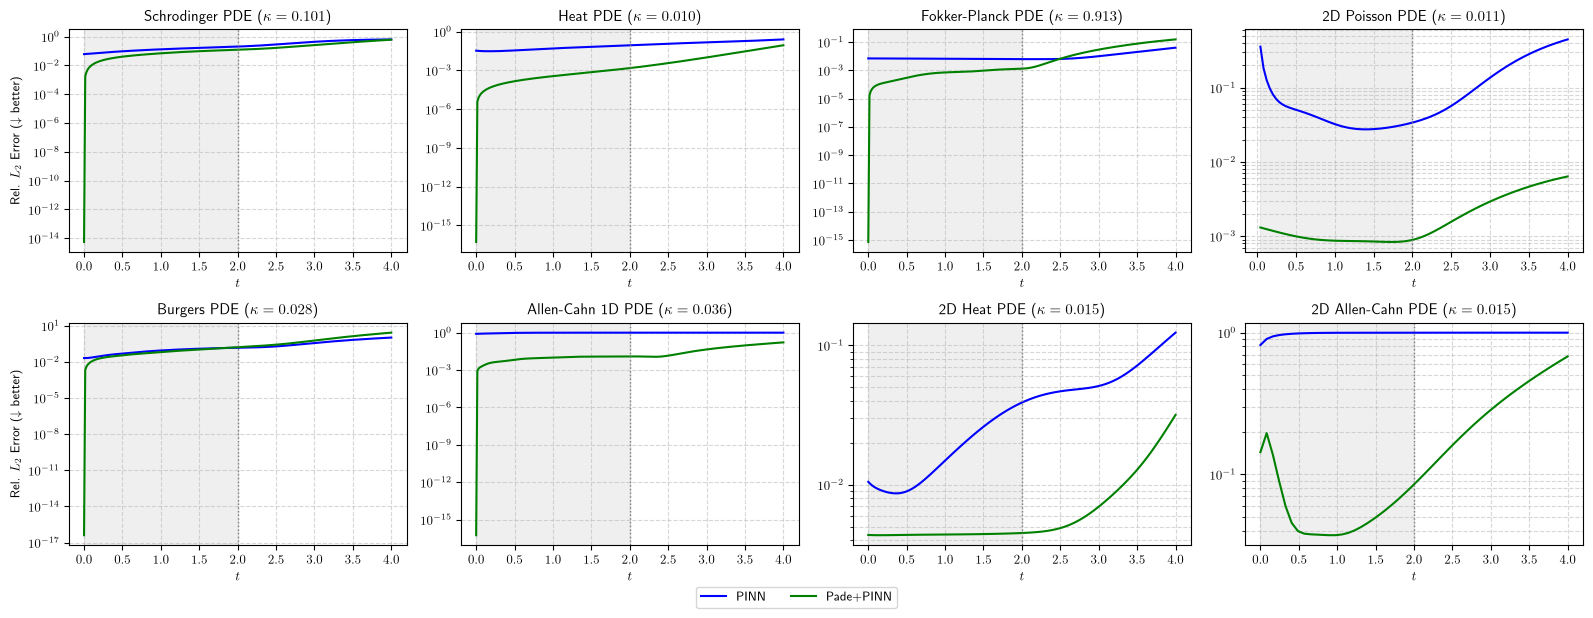

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

# Rel. L2 error vs t, extended to 2x the training horizon. Shaded band + dotted line mark where
# training data ends (t=duration) -- everything past it is pure extrapolation.
for ax, (type_, cfg) in zip(axes[0], pde_configs.items()):
    d = extrap_data[type_]
    ax.axvspan(d['t_plot'][0], d['duration'], color='gray', alpha=0.12, zorder=0)
    ax.semilogy(d['t_plot'], d['l2_pinn'], color='blue', linewidth=1.5, label='PINN')
    ax.semilogy(d['t_plot'], d['l2_pade_pinn'], color='green', linewidth=1.5, label='Pade+PINN')
    ax.axvline(d['duration'], color='gray', linestyle=':', linewidth=1)
    ax.set_title(fr'{cfg["title"]}  ($\kappa={d["kappa"]:.3f}$)')
    ax.set_xlabel(r'$t$')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

axes[0, 0].set_ylabel(r'Rel. $L_2$ Error ($\downarrow$ better)')

for ax, (type_, cfg) in zip(axes[1], pde_configs2.items()):
    d = extrap_data2[type_]
    ax.axvspan(d['t_plot'][0], d['duration'], color='gray', alpha=0.12, zorder=0)
    ax.semilogy(d['t_plot'], d['l2_pinn'], color='blue', linewidth=1.5, label='PINN')
    ax.semilogy(d['t_plot'], d['l2_pade_pinn'], color='green', linewidth=1.5, label='Pade+PINN')
    ax.axvline(d['duration'], color='gray', linestyle=':', linewidth=1)
    ax.set_title(fr'{cfg["title"]}  ($\kappa={d["kappa"]:.3f}$)')
    ax.set_xlabel(r'$t$')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

axes[1, 0].set_ylabel(r'Rel. $L_2$ Error ($\downarrow$ better)')

handles = [plt.Line2D([0], [0], color='blue', lw=1.5), plt.Line2D([0], [0], color='green', lw=1.5)]
fig.legend(handles, ["PINN", "Pade+PINN"], loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.03), frameon=True)
plt.tight_layout()
plt.savefig('./figs/error/extrapolation_horizon_comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()